## Generate plots to show the distributions of the failed versus passing single-cells in the data

We use the `PCCMA optimization` dataset.

In [1]:
from pathlib import Path

import pandas as pd
from plotnine import (
    aes,
    element_text,
    geom_histogram,
    geom_hline,
    geom_point,
    geom_vline,
    ggplot,
    ggtitle,
    labs,
    scale_color_manual,
    scale_fill_manual,
    theme,
    theme_light,
)
from plotnine.options import set_option

from cosmicqc import identify_outliers

## Set paths and variables

In [2]:
# Set output directory for figures
output_dir = Path("./figures")
output_dir.mkdir(parents=True, exist_ok=True)

# Load the data to generate the plots
example_df = pd.read_parquet(
    Path(
        "/media/18tbdrive/1.Github_Repositories/pediatric_cancer_atlas_profiling/3.preprocessing_features/data/converted_profiles/Round_2_data/BR00145816_converted.parquet"
    )
)

# metadata columns to include in output data frame
metadata_columns = [
    "Image_Metadata_Plate",
    "Image_Metadata_Well",
    "Image_Metadata_Site",
    "Metadata_Nuclei_Location_Center_X",
    "Metadata_Nuclei_Location_Center_Y",
    "Image_FileName_OrigDNA",
    "Image_FileName_OrigAGP",
    "Image_PathName_OrigDNA",
    "Image_PathName_OrigAGP",
    "Nuclei_AreaShape_BoundingBoxMaximum_X",
    "Nuclei_AreaShape_BoundingBoxMaximum_Y",
    "Nuclei_AreaShape_BoundingBoxMinimum_X",
    "Nuclei_AreaShape_BoundingBoxMinimum_Y",
]

# Define the QC features
qc_features = [
    "Nuclei_Intensity_IntegratedIntensity_CorrDNA",
    "Nuclei_AreaShape_Solidity",
    "Nuclei_Intensity_MassDisplacement_CorrDNA",
]

# Filter plate_df to only include metadata columns and QC features
filtered_plate_df = example_df[metadata_columns + qc_features]

print(example_df.shape)
example_df.head()

(78602, 3035)


,Metadata_Nuclei_Location_Center_X,Metadata_Nuclei_Location_Center_Y,Metadata_Cells_Location_Center_X,Metadata_Cells_Location_Center_Y,Metadata_Image_Count_Cells,Metadata_ImageNumber,Image_Metadata_Col,Image_Metadata_Plate,Image_Metadata_Row,Image_Metadata_Site,...,Nuclei_Texture_Variance_CorrER_3_02_256,Nuclei_Texture_Variance_CorrER_3_03_256,Nuclei_Texture_Variance_CorrMito_3_00_256,Nuclei_Texture_Variance_CorrMito_3_01_256,Nuclei_Texture_Variance_CorrMito_3_02_256,Nuclei_Texture_Variance_CorrMito_3_03_256,Nuclei_Texture_Variance_CorrRNA_3_00_256,Nuclei_Texture_Variance_CorrRNA_3_01_256,Nuclei_Texture_Variance_CorrRNA_3_02_256,Nuclei_Texture_Variance_CorrRNA_3_03_256
0,336.377009,104.297899,352.210413,116.052065,10,1,1,BR00145816,2,1,...,189.867760,175.258056,9.359696,9.455868,9.342000,8.864129,71.653567,78.652402,72.325106,67.668053
1,498.383356,81.555252,493.371429,74.367347,14,6,1,BR00145816,2,6,...,37.010230,42.539795,2.056842,2.040540,2.121985,2.797201,6.598058,6.854488,6.605123,6.568223
2,296.924490,42.889796,290.397623,54.289762,18,7,1,BR00145816,2,7,...,229.314572,218.190815,10.576748,10.938701,9.687250,8.795027,63.617244,65.864101,63.804281,64.184465
3,787.229535,286.391653,783.873688,289.240187,10,8,1,BR00145816,2,8,...,1496.307081,1538.527119,136.357027,127.891993,140.240277,141.944781,261.830682,243.596874,249.175994,255.187774
4,891.834437,104.026490,892.879444,102.732612,16,22,1,BR00145816,4,4,...,159.236979,153.487704,3.661602,3.331812,3.183244,3.233278,10.138008,9.798398,9.062918,8.676421


In [3]:
# Find large nuclei outliers for the current plate
identify_nuclei_clustered_outliers = identify_outliers(
    df=filtered_plate_df,
    feature_thresholds={
        # Set very low as to detect all instances of clustering nuclei
        "Nuclei_Intensity_MassDisplacement_CorrDNA": 0.05,
        # Set higher than displacement to avoid false positives
        "Nuclei_Intensity_IntegratedIntensity_CorrDNA": 1.5,
    },
    include_threshold_scores=True,
)

pd.DataFrame(identify_nuclei_clustered_outliers).head()

,cqc.custom.Z_Score.Nuclei_Intensity_MassDisplacement_CorrDNA,cqc.custom.Z_Score.Nuclei_Intensity_IntegratedIntensity_CorrDNA,cqc.custom.is_outlier
0,0.878023,-0.267815,False
1,-0.498469,-0.569057,False
2,-0.892600,-0.616416,False
3,1.273175,1.272925,False
4,-0.640144,-0.684732,False


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 5 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: figures/over_segmented_nuclei_plot.png


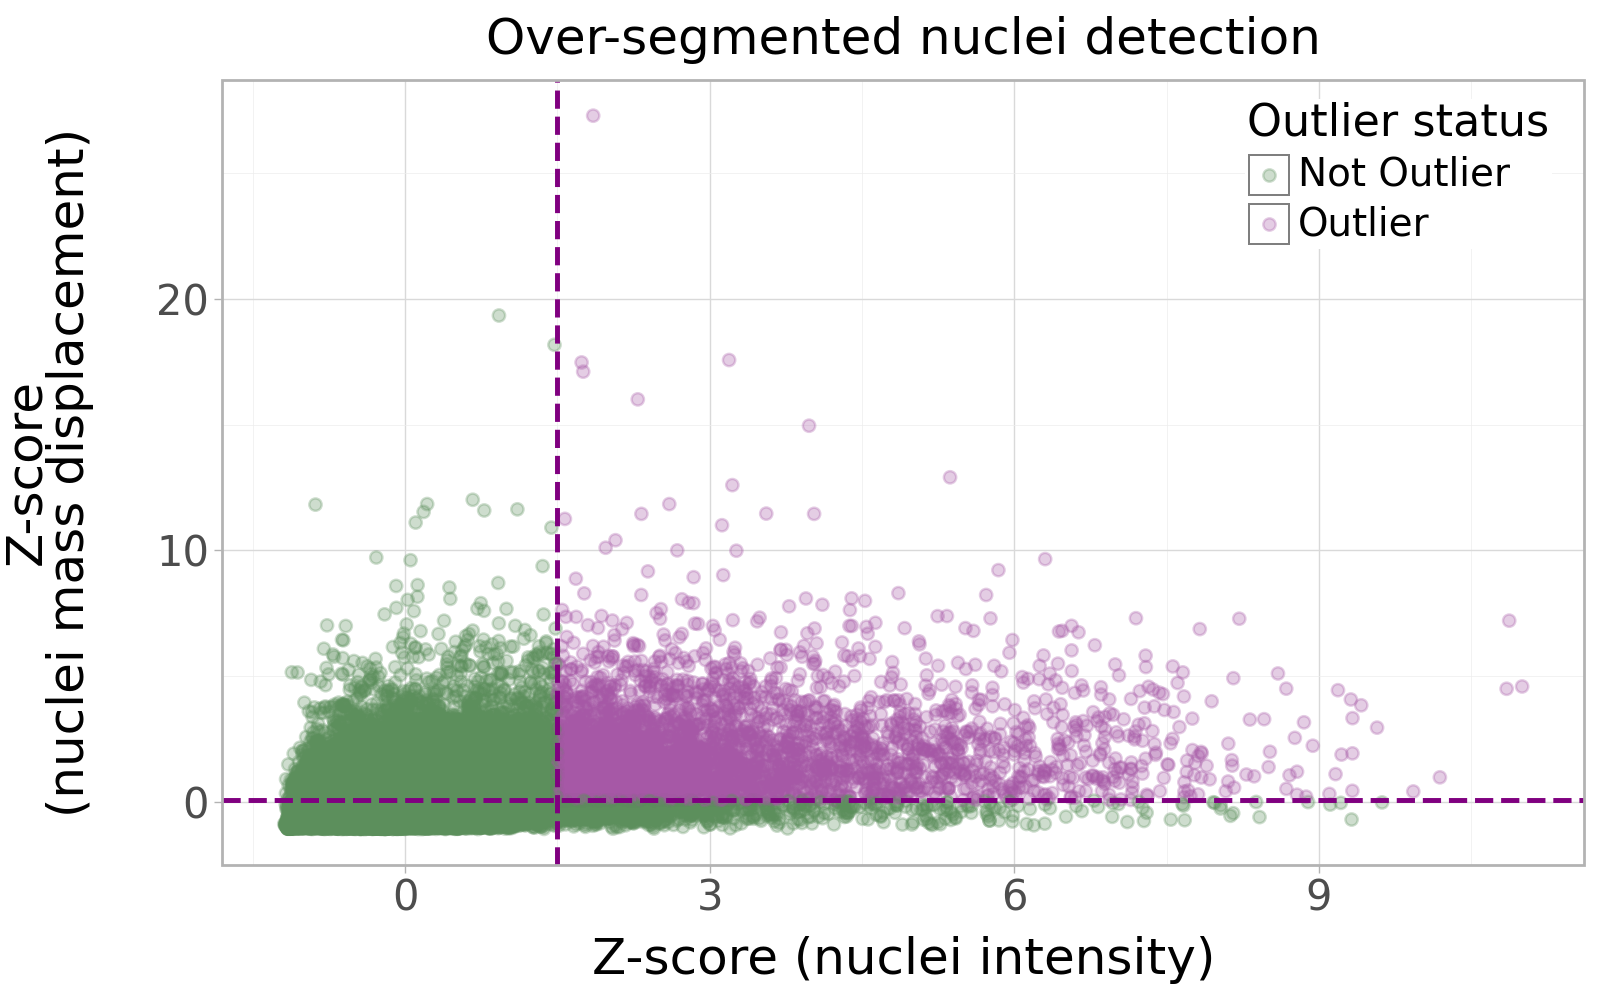

In [4]:
# Rename for easier access
df = identify_nuclei_clustered_outliers.rename(
    columns={
        "cqc.custom.Z_Score.Nuclei_Intensity_IntegratedIntensity_CorrDNA": "zscore_intensity",
        "cqc.custom.Z_Score.Nuclei_Intensity_MassDisplacement_CorrDNA": "zscore_displacement",
        "cqc.custom.is_outlier": "is_outlier",
    }
)

# Make sure 'is_outlier' is a string or category (for coloring)
df["is_outlier"] = df["is_outlier"].map({True: "Outlier", False: "Not Outlier"})

# Set the figure size
height = 5
width = 8
set_option("figure_size", (width, height))

# Plot
p = (
    ggplot(df, aes(x="zscore_intensity", y="zscore_displacement", color="is_outlier"))
    + geom_point(alpha=0.3, size=2)
    + geom_vline(xintercept=1.5, linetype="--", color="#800080", size=1.0)
    + geom_hline(yintercept=0.05, linetype="--", color="#800080", size=1.0)
    + scale_color_manual(values={"Outlier": "#A658A6", "Not Outlier": "#5C8F5C"})
    + labs(
        x="Z-score (nuclei intensity)",
        y="Z-score\n(nuclei mass displacement)",
        color="Outlier status",
    )
    + ggtitle("Over-segmented nuclei detection")
    + theme_light()
    + theme(
        legend_title=element_text(size=16),
        legend_text=element_text(size=14),
        legend_position=(0.97, 0.97),
        axis_title=element_text(size=18),
        axis_text=element_text(size=15),
        plot_title=element_text(size=18),
        axis_title_y=element_text(
            angle=90,
            vjust=0.5,
            ha="center",
            size=18,
        ),
        plot_margin_left=0.03,
    )
)
# Save the plot
p.save(
    output_dir / "over_segmented_nuclei_plot.png", dpi=600, width=width, height=height
)

p.show()

In [5]:
# Find large nuclei outliers for the current plate
identify_poor_nuclei_shape_outliers = identify_outliers(
    df=filtered_plate_df,
    # Set at this point where it looks like it starts to detect good quality nuclei
    feature_thresholds={
        "Nuclei_AreaShape_Solidity": -1.6,
    },
    include_threshold_scores=True,
)

pd.DataFrame(identify_poor_nuclei_shape_outliers).head()

,cqc.custom.Z_Score.Nuclei_AreaShape_Solidity,cqc.custom.is_outlier
0,0.373790,False
1,0.180780,False
2,0.515060,False
3,-0.179293,False
4,0.642143,False


/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:615: PlotnineWarning: Saving 8 x 5 in image.
/home/jenna/.cache/pypoetry/virtualenvs/cosmicqc-vNopUmqk-py3.11/lib/python3.11/site-packages/plotnine/ggplot.py:616: PlotnineWarning: Filename: figures/pooly_segmented_nuclei_plot.png


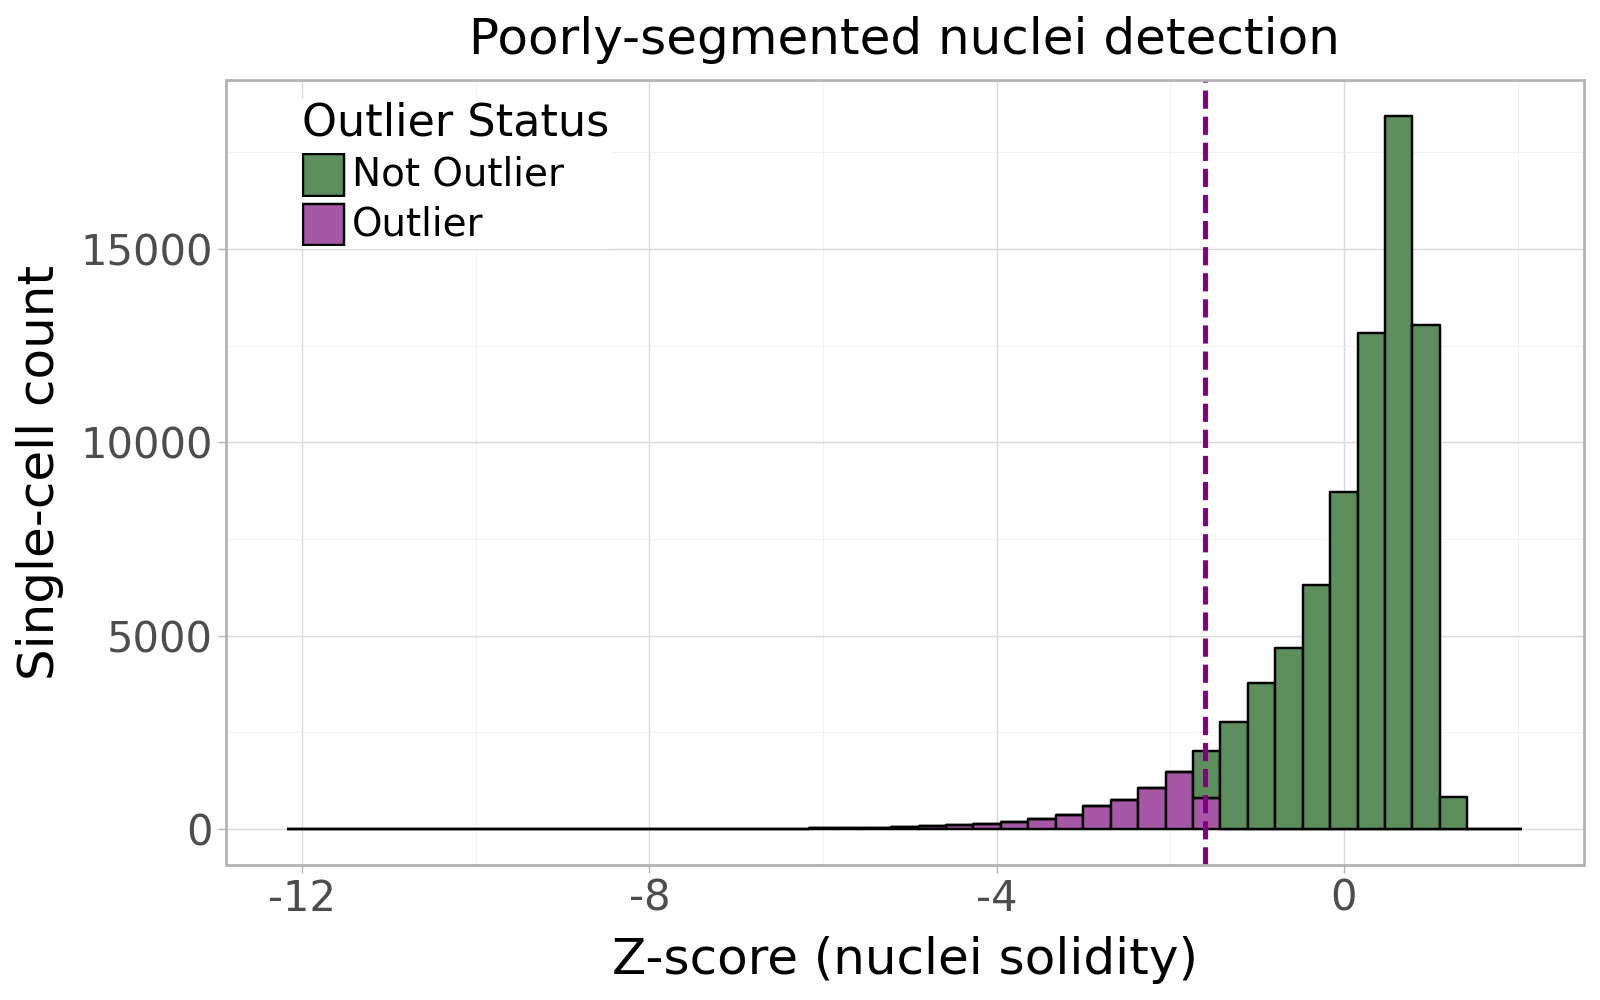

In [6]:
# Rename for easier access
df = identify_poor_nuclei_shape_outliers.rename(
    columns={
        "cqc.custom.Z_Score.Nuclei_AreaShape_Solidity": "zscore_solidity",
        "cqc.custom.is_outlier": "is_outlier",
    }
)

# Make sure 'is_outlier' is a string or category (for coloring)
df["is_outlier"] = df["is_outlier"].map({True: "Outlier", False: "Not Outlier"})

# Set the figure size
set_option("figure_size", (width, height))

p = (
    ggplot(df, aes(x="zscore_solidity", fill="is_outlier"))
    + geom_histogram(position="stack", bins=45, color="black")
    + scale_fill_manual(values={"Not Outlier": "#5C8F5C", "Outlier": "#A658A6"})
    + geom_vline(
        xintercept=df.loc[df["is_outlier"] == "Outlier", "zscore_solidity"].max(),
        linetype="dashed",
        color="#800080",
        size=1.0,
    )
    + labs(x="Z-score (nuclei solidity)", y="Single-cell count", fill="Outlier Status")
    + ggtitle("Poorly-segmented nuclei detection")
    + theme_light()
    + theme(
        legend_title=element_text(size=16),
        legend_text=element_text(size=14),
        legend_position=(0.07, 0.97),
        axis_title=element_text(size=18),
        axis_text=element_text(size=15),
        plot_title=element_text(
            size=18,
        ),
    )
)

# Save the plot
p.save(
    output_dir / "pooly_segmented_nuclei_plot.png", dpi=600, width=width, height=height
)

p.show()